Introduction to the Dataset:

Download the dataset from Kaggle.
Load the dataset using Pandas.
Perform initial exploration to understand the dataset structure : whats the distribution of the data? What types of data do i have?
Data Cleaning:

Identify and handle missing values.
Detect and correct any inconsistencies in the data.
Drop irrelevant columns if necessary.




In [101]:
import pandas as pd
mental_health = pd.read_csv('survey.csv')
df= mental_health.copy()
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [102]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [103]:
df.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

In [104]:
df.shape

(1259, 27)

In [105]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [106]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


cleaning age column

<Axes: xlabel='Age'>

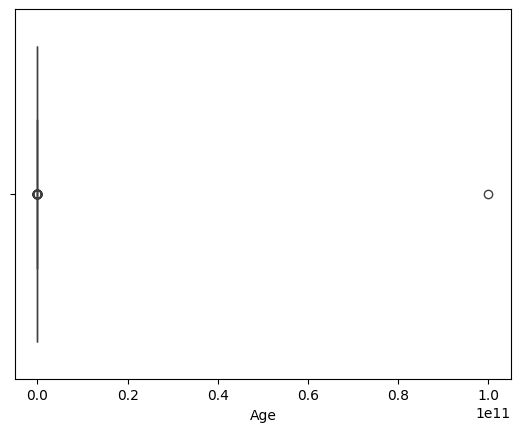

In [107]:
import seaborn as sns
sns.boxplot(x=df['Age'])    

In [108]:
df['Age']=df[(df['Age']>0) & (df['Age']<120)]['Age']
age_98 =df['Age'].quantile(1)
age_25 =df['Age'].quantile(0.01)
print(age_98)
print(age_25)

72.0
19.0


<Axes: xlabel='Age'>

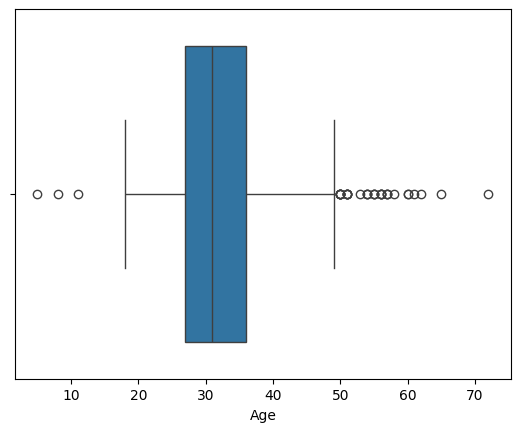

In [109]:
sns.boxplot(x=df['Age'])

In [110]:
print(df['Age'].isnull().sum())

5


In [135]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [112]:
df.shape

(1259, 27)

<Axes: xlabel='Age', ylabel='Count'>

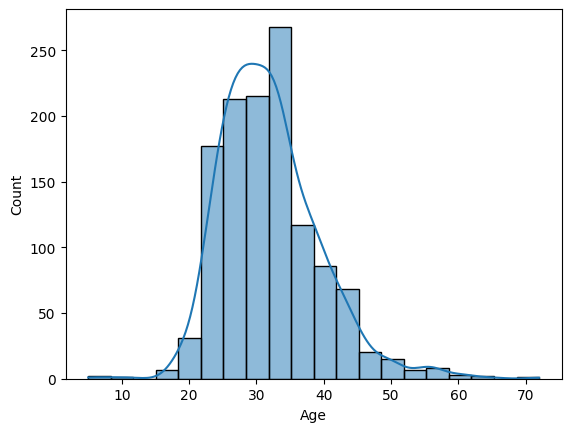

In [136]:
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True)



Now the Age column is fixed

cleaning gender column

In [114]:
df['Gender'].unique()

array(['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile',
       'Trans-female', 'Cis Female', 'F', 'something kinda male?',
       'Cis Male', 'Woman', 'f', 'Mal', 'Male (CIS)', 'queer/she/they',
       'non-binary', 'Femake', 'woman', 'Make', 'Nah', 'All', 'Enby',
       'fluid', 'Genderqueer', 'Female ', 'Androgyne', 'Agender',
       'cis-female/femme', 'Guy (-ish) ^_^', 'male leaning androgynous',
       'Male ', 'Man', 'Trans woman', 'msle', 'Neuter', 'Female (trans)',
       'queer', 'Female (cis)', 'Mail', 'cis male', 'A little about you',
       'Malr', 'p', 'femail', 'Cis Man',
       'ostensibly male, unsure what that really means'], dtype=object)

In [142]:

gender_mapping={'Female':'Female', 'M':'Male', 'Male':'Male', 'male':'Male', 'female':'Female', 'm':'Male', 'Male-ish':'Male', 'maile':'Male',
       'Trans-female':'Transgender', 'Cis Female':'Female', 'F':'Female', 'something kinda male?':'Unknown',
       'Cis Male':'Male', 'Woman':'Female', 'f':'Female', 'Mal':'Male', 'Male (CIS)':'Male', 'queer/she/they':'Unknown',
       'non-binary':'Unknown', 'Femake':'Female', 'woman':'Female', 'Make':'Male', 'Nah':'Unknown', 'All':'Unknown', 'Enby':'Unknown',
       'fluid':'Unknown', 'Genderqueer':'Unknown', 'Female ':'Female', 'Androgyne':'Male', 'Agender':'Unknown',
       'cis-female/femme':'Female', 'Guy (-ish) ^_^':'Unknown', 'male leaning androgynous':'Male',
       'Male':'Male', 'Man':'Male', 'Trans woman':'Transgender', 'msle':'Unknown', 'Neuter':'Unknown', 'Female (trans)':'Female',
       'queer':'Unknown', 'Female (cis)':'Female', 'Mail':'Male', 'cis male':'Male', 'A little about you':'Unknown',
       'Malr':'Male', 'p':'Unknown', 'femail':'Female', 'Cis Man':'Male',
       'ostensibly male, unsure what that really means':'Unknown'}

In [141]:
df['gender'].isnull().sum()

np.int64(1138)

In [143]:
df['gender'] = df['Gender'].map(gender_mapping)
df['gender'].unique()
print(df['gender'].value_counts())
df.shape

gender
Male           976
Female         244
Unknown         16
Transgender      2
Name: count, dtype: int64


(1241, 26)

<Axes: xlabel='gender', ylabel='count'>

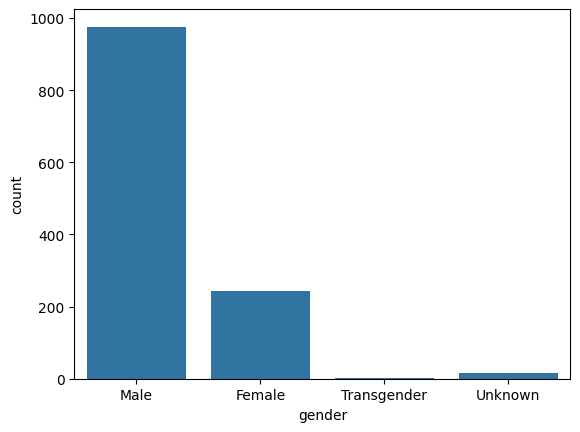

In [144]:
sns.countplot(x='gender', data=df)

In [145]:
df.isnull().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
gender                       3
dtype: int64

In [146]:
df['gender'] = df['gender'].fillna('Unknown')

In [147]:
df.isnull().sum()

Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
gender                       0
dtype: int64

Now the gender column is fixed

moving to missing values in work_interfere column

In [118]:
work_miss=df[df['work_interfere'].isnull()]
print(work_miss)
print(f'percentage of missing work_interfere values: {len(work_miss)/len(df)*100:.2f}%')

                Timestamp   Age  Gender         Country state self_employed  \
19    2014-08-27 11:35:08  36.0    Male          France   NaN           Yes   
26    2014-08-27 11:37:23  33.0    male   United States    TN            No   
37    2014-08-27 11:41:50  38.0    Male        Portugal   NaN            No   
38    2014-08-27 11:42:08  50.0       M   United States    IN            No   
41    2014-08-27 11:42:31  35.0    Male   United States    MI            No   
...                   ...   ...     ...             ...   ...           ...   
1226  2015-02-21 17:19:18  39.0    Male     Netherlands   NaN            No   
1229  2015-02-22 02:40:32  39.0    Male          Greece   NaN            No   
1244  2015-05-05 15:16:25  32.0  female  United Kingdom   NaN            No   
1254  2015-09-12 11:17:21  26.0    male  United Kingdom   NaN            No   
1257  2015-11-30 21:25:06  46.0       f   United States    NC            No   

     family_history treatment work_interfere    no_

In [119]:
df['work_interfere'].unique

<bound method Series.unique of 0           Often
1          Rarely
2          Rarely
3           Often
4           Never
          ...    
1254          NaN
1255        Often
1256    Sometimes
1257          NaN
1258    Sometimes
Name: work_interfere, Length: 1259, dtype: object>

<Axes: xlabel='work_interfere'>

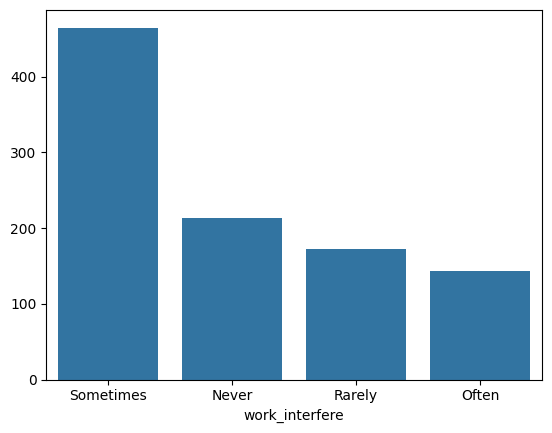

In [120]:
import seaborn as sns
counts = df['work_interfere'].value_counts()
sns.barplot(x=counts.index, y=counts.values)

<Axes: xlabel='work_interfere', ylabel='count'>

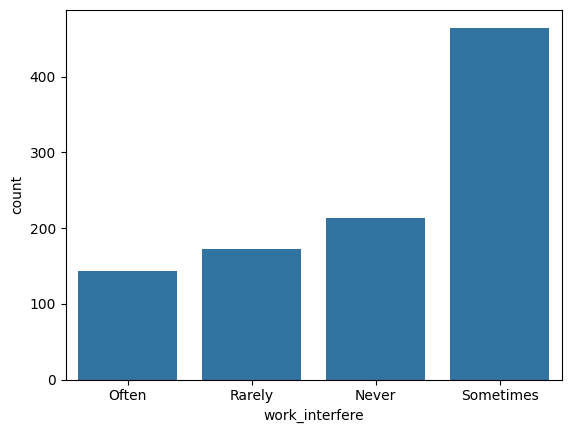

In [121]:
sns.countplot(x='work_interfere', data=df)

since the work_interfere column is important to the dataset and the 'missing values' is significant, its fill with unknown

In [122]:
df['work_interfere']=df['work_interfere'].fillna('Unknown')

In [123]:
df['work_interfere'].value_counts()

work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

work_interfere column is fixed


moving to self employed column

In [124]:
self_employ_miss=df[df['self_employed'].isnull()] 
print(self_employ_miss.head())
print(f'percentage of missing self_employed values: {len(self_employ_miss)/len(df)*100:.2f}%')

             Timestamp   Age  Gender         Country state self_employed  \
0  2014-08-27 11:29:31  37.0  Female   United States    IL           NaN   
1  2014-08-27 11:29:37  44.0       M   United States    IN           NaN   
2  2014-08-27 11:29:44  32.0    Male          Canada   NaN           NaN   
3  2014-08-27 11:29:46  31.0    Male  United Kingdom   NaN           NaN   
4  2014-08-27 11:30:22  31.0    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

  mental_health_consequence phys_health_consequence     coworkers supervisor  \
0                        No                      No  Some of them 

<Axes: xlabel='self_employed', ylabel='count'>

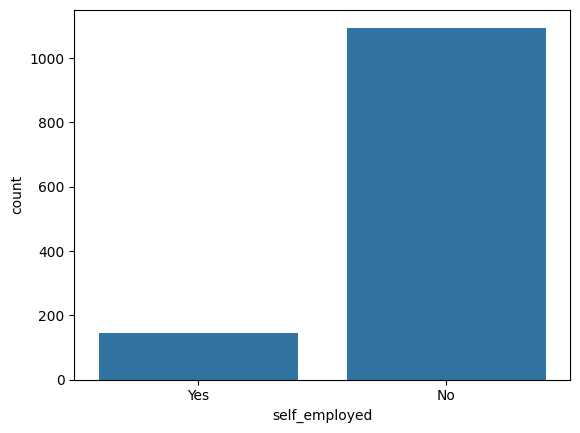

In [125]:
sns.countplot(x='self_employed', data=df)

since the missing values is only 18, the rows are deleted 

In [126]:
df=df.dropna(subset=['self_employed'])

self_employed column is fixed

In [127]:
state_miss=df[df['state'].isnull()]
print(state_miss)
print(f'percentage of missing state values: {len(state_miss)/len(df)*100:.2f}%')    

                Timestamp   Age  Gender         Country state self_employed  \
19    2014-08-27 11:35:08  36.0    Male          France   NaN           Yes   
29    2014-08-27 11:38:18  37.0    Male  United Kingdom   NaN            No   
30    2014-08-27 11:39:03  32.0    Male  United Kingdom   NaN            No   
32    2014-08-27 11:39:31  30.0    male  United Kingdom   NaN            No   
36    2014-08-27 11:41:37  29.0    Male          Canada   NaN            No   
...                   ...   ...     ...             ...   ...           ...   
1244  2015-05-05 15:16:25  32.0  female  United Kingdom   NaN            No   
1245  2015-05-06 10:14:50  22.0    Male       Australia   NaN            No   
1247  2015-05-07 10:08:50  36.0    male         Finland   NaN            No   
1251  2015-08-17 09:38:35  36.0    Male    South Africa   NaN            No   
1254  2015-09-12 11:17:21  26.0    male  United Kingdom   NaN            No   

     family_history treatment work_interfere    no_

since the missing values are almost half the roles, its dropped

In [128]:
df= df.drop('state', axis =1)

state column is fixed

moving to columns

In [129]:
comment_miss= df[df['comments'].isnull()]
print(comment_miss.head())
print(f'percentage of missing comment values: {len(comment_miss)/len(df)*100:.2f}%')

              Timestamp   Age Gender        Country self_employed  \
18  2014-08-27 11:34:53  46.0   male  United States           Yes   
19  2014-08-27 11:35:08  36.0   Male         France           Yes   
20  2014-08-27 11:35:12  29.0   Male  United States            No   
21  2014-08-27 11:35:24  31.0   male  United States           Yes   
22  2014-08-27 11:35:48  46.0   Male  United States            No   

   family_history treatment work_interfere no_employees remote_work  ...  \
18            Yes        No      Sometimes          1-5         Yes  ...   
19            Yes        No        Unknown         6-25         Yes  ...   
20            Yes       Yes      Sometimes      100-500          No  ...   
21             No        No          Never          1-5         Yes  ...   
22             No       Yes          Often       26-100         Yes  ...   

   mental_health_consequence phys_health_consequence     coworkers  \
18                        No                      No      

since missing values are almost 90%, the comments column is dropped 

In [130]:
df=df.drop('comments', axis=1)

the comments section is taken off from the dataset

In [131]:
df.shape

(1241, 26)

In [148]:
df.isnull().sum()


Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
gender                       0
dtype: int64

now there is no missing values in the dataset

In [133]:
df.duplicated().sum()

np.int64(0)

no duplicate found